In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import ruptures as rpt
import multiprocessing
from concurrent import futures
from tqdm import tqdm

import sys

sys.path.append("../..")

from src import IOFunctions
from IPython.display import display, clear_output

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

/tmp/ipykernel_2387787/1292142682.py:20: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [2]:
dye_data_folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/FRET/20pM_HJ_200mM_MgCl2'

In [3]:
all_h5_files = H_F.file_search(dye_data_folder, ".h5", "")

# Exclude any previously-saved changepoint files so we don't re-process them
loc_files = [f for f in all_h5_files if not f.endswith('_colourchangepoint.h5')]
changepoint_files = [f for f in all_h5_files if f.endswith('_colourchangepoint.h5')]
print(f"Found {len(loc_files)} analysis H5 files to process")
for i, f in enumerate(loc_files):
    out_path = os.path.splitext(f)[0] + '_colourchangepoint.h5'
    status = "EXISTS" if os.path.exists(out_path) else "pending"
    print(f"  [{i:02d}] {os.path.basename(f)}  [{status}]")

Found 25 analysis H5 files to process
  [00] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_000.h5  [EXISTS]
  [01] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_001.h5  [EXISTS]
  [02] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_002.h5  [EXISTS]
  [03] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_003.h5  [EXISTS]
  [04] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_004.h5  [EXISTS]
  [05] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_000.h5  [EXISTS]
  [06] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_001.h5  [EXISTS]
  [07] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_002.h5  [EXISTS]
  [08] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_003.h5  [EXISTS]
  [09] 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposur

In [4]:
tiff_files = H_F.file_search(dye_data_folder, ".tif", "")
print(f"Found {len(tiff_files)} tiff files")
for i, f in enumerate(tiff_files):
    print(f"  [{i}]: {os.path.basename(f)}")

Found 25 tiff files
  [0]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_000.ome.tif
  [1]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_001.ome.tif
  [2]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_002.ome.tif
  [3]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_003.ome.tif
  [4]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_004.ome.tif
  [5]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_000.ome.tif
  [6]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_001.ome.tif
  [7]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_002.ome.tif
  [8]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_003.ome.tif
  [9]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_004.ome.tif
  [10]: 20pM_HJ_20p561_568lp_D

In [5]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r488-561-t1-25x36"
dichroic_mirror_all = "semrock-di03-r405-488-561-635-t1-25x36"
shortpass_filter = "semrock-bsp01-785r"
longpass_red_filter = "semrock-blp01-635r"

longpass_filter = "semrock-blp01-568r"
objective_T = S_F.getobjectiveefficiency(wavelength)
filters = [dichroic_mirror, longpass_filter,shortpass_filter]
dye = "Cy3"
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
)
dye_pixel_efficiency_Cy3 = dye_pixel_efficiency / np.sum(dye_pixel_efficiency)

filter_spectrum = np.prod(
    S_F.get_dye_or_filter_data(
        names=filters, wavelength=wavelength, dye_or_filter=False
    ),
    axis=0,
)

filter_spectrum = filter_spectrum*objective_T


cy3_spectra = S_F.get_dye_or_filter_data(
    dye, wavelength=wavelength
)
cy3_at_detector_spectra = np.array(
    np.multiply(cy3_spectra, filter_spectrum).T
    / np.sum(np.multiply(cy3_spectra, 1), axis=1)
).T
Detection_Cy3 = np.sum(cy3_at_detector_spectra*pixel_QYs)

dye = "Cy5"
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
)
dye_pixel_efficiency_Cy5 = dye_pixel_efficiency / np.sum(dye_pixel_efficiency)
cy5_spectra = S_F.get_dye_or_filter_data(
    dye, wavelength=wavelength
)
cy5_at_detector_spectra = np.array(
    np.multiply(cy5_spectra, filter_spectrum).T
    / np.sum(np.multiply(cy5_spectra, 1), axis=1)
).T
Detection_Cy5 = np.sum(cy5_at_detector_spectra*pixel_QYs)


print(f"Cy3 pixel efficiencies (B, G, R): {dye_pixel_efficiency_Cy3}")
print(f"Cy5 pixel efficiencies (B, G, R): {dye_pixel_efficiency_Cy5}")

Cy3 pixel efficiencies (B, G, R): [0.02105954 0.3841594  0.59478107]
Cy5 pixel efficiencies (B, G, R): [0.0597494  0.18662932 0.75362128]


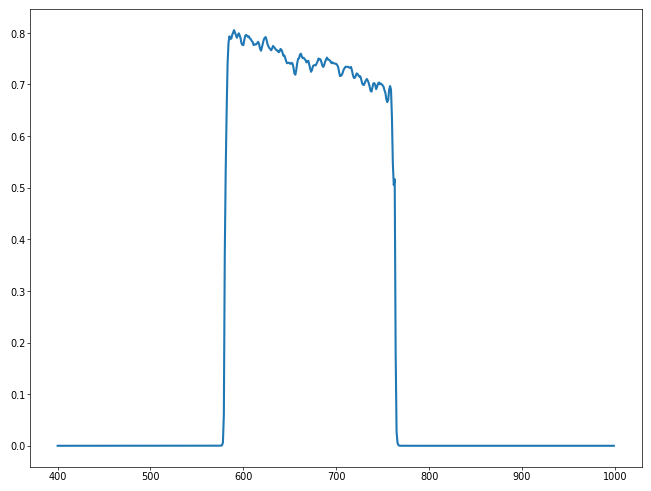

In [6]:
plt.plot(wavelength,filter_spectrum)

[0.02979344 0.09331046 0.37985469]


0.502958595428478

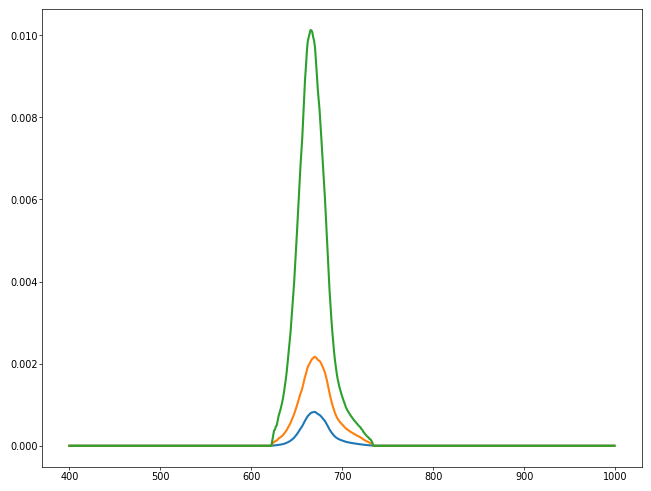

In [7]:
plt.plot(wavelength,pixel_QYs.T*cy5_at_detector_spectra.T)
print(np.sum(pixel_QYs*cy5_at_detector_spectra,1))
np.sum(pixel_QYs*cy5_at_detector_spectra)

[0.00517752 0.0977768  0.14688579]


0.24984011240570875

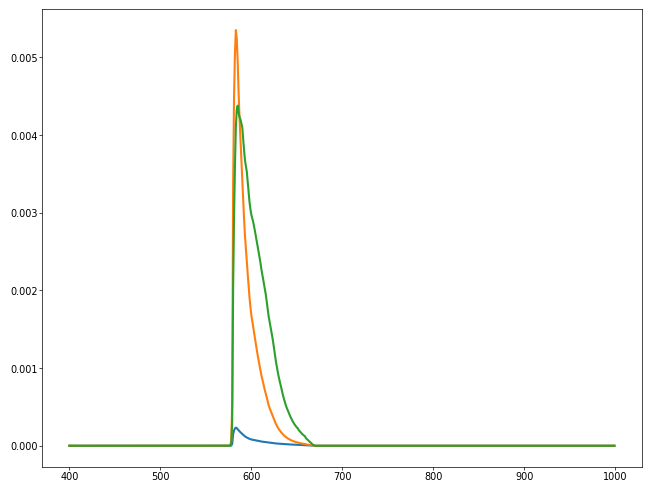

In [8]:
plt.plot(wavelength,pixel_QYs.T*cy3_at_detector_spectra.T)
print(np.sum(pixel_QYs*cy3_at_detector_spectra,1))
np.sum(pixel_QYs*cy3_at_detector_spectra)

0.0051775181026532
0.1955536097132144
0.14688578944644837
0.02979343643838442
0.18662092917869627
0.3798546944007455


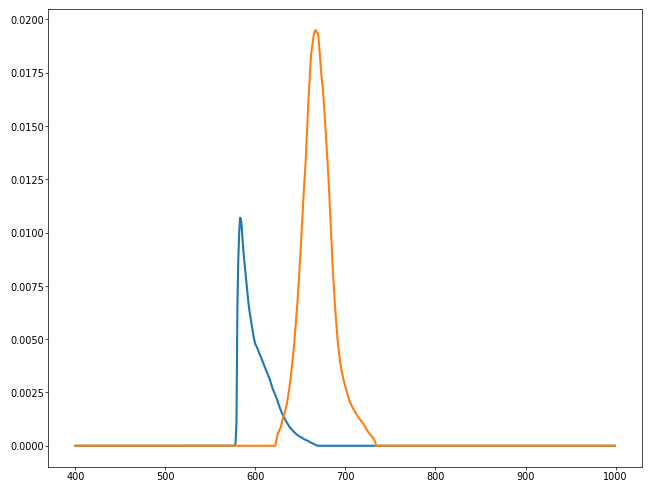

In [9]:
plt.plot(wavelength,cy3_at_detector_spectra.T)
test = cy3_at_detector_spectra*pixel_QYs
print(np.sum(test[0]))
print(2*np.sum(test[1]))
print(np.sum(test[2]))

plt.plot(wavelength,cy5_at_detector_spectra.T)
test = cy5_at_detector_spectra*pixel_QYs
print(np.sum(test[0]))
print(2*np.sum(test[1]))
print(np.sum(test[2]))



In [10]:
def load_changepoint_analysis(changepoint_h5_path):
    """Load all tables from a _colourchangepoint.h5 file.

    Convenience reader for the plotting notebook.  Returns the three tables
    written by save_changepoint_results() so you can immediately plot traces,
    segment means, or aggregate statistics without recomputing anything.

    Usage example::

        df_data, cp_df, seg_df = load_changepoint_analysis(path)

        # plot segment means for one punctum
        pid = 42
        sub  = df_data[df_data['puncta_id'] == pid].sort_values('frame')
        segs = seg_df[seg_df['puncta_id'] == pid]
        cps  = cp_df[cp_df['puncta_id'] == pid]

        t = sub['frame'].values * exposure_time
        plt.scatter(t, sub['A_R'], s=4, c='red')
        for _, row in segs.iterrows():
            plt.hlines(row['A_R_mean'],
                       row['frame_start'] * exposure_time,
                       row['frame_end']   * exposure_time,
                       colors='darkred', lw=2)
        for _, cp in cps.iterrows():
            plt.axvline(cp['frame'] * exposure_time, ls='--', color='k')

    Args:
        changepoint_h5_path (str): Path to a *_colourchangepoint.h5 file.

    Returns:
        tuple:
            df_data (pd.DataFrame): Filtered localisation data.
            cp_df   (pd.DataFrame): Change-points table.
            seg_df  (pd.DataFrame): Segment-statistics table.
    """
    df_data = pd.read_hdf(changepoint_h5_path, key='data')
    cp_df   = pd.read_hdf(changepoint_h5_path, key='changepoints')
    seg_df  = pd.read_hdf(changepoint_h5_path, key='segments')
    return df_data, cp_df, seg_df


In [11]:
[df_data, cp_df, seg_df] = load_changepoint_analysis(changepoint_files[0])

In [12]:
cp_puncta_ids = df_data['puncta_id'].unique()
cp_puncta_ids = np.sort(cp_puncta_ids)

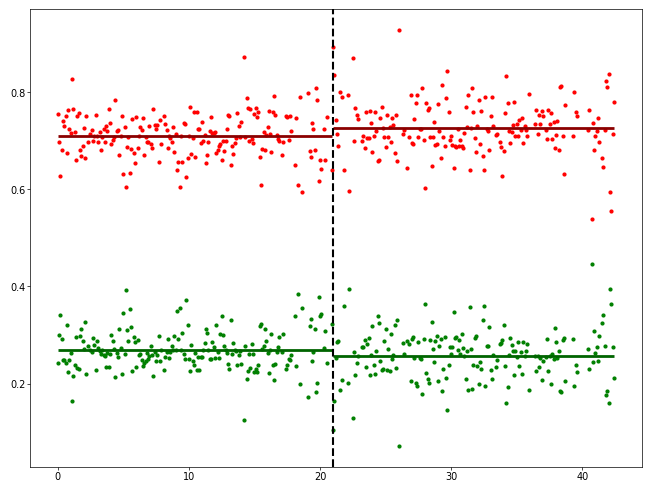

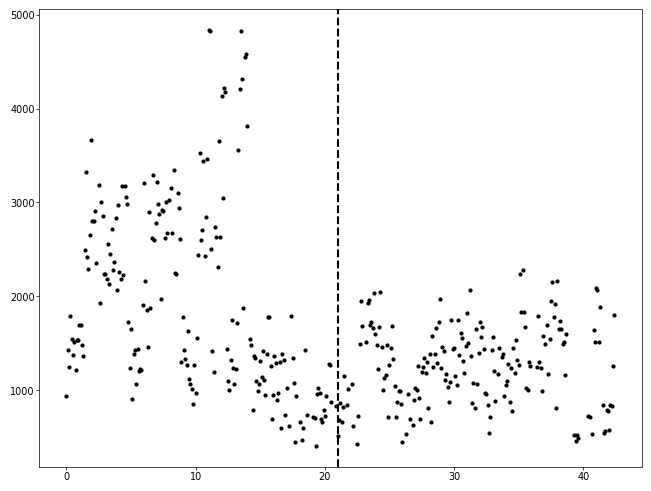

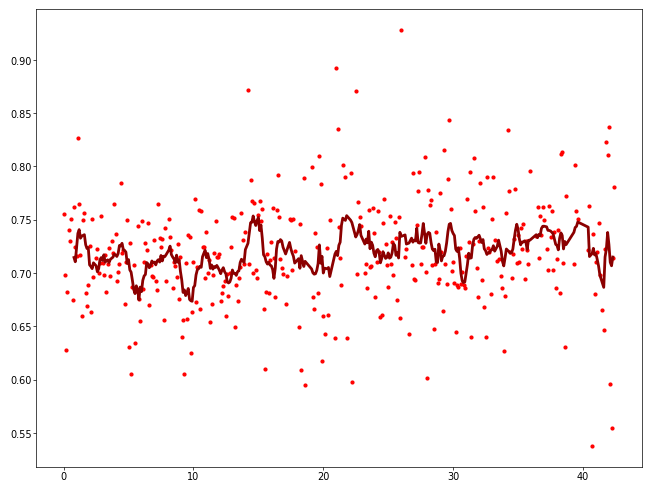

In [13]:
# plot segment means for one punctum, 9, 14,15,20
exposure_time = 0.1
pid = cp_puncta_ids[4]
sub  = df_data[df_data['puncta_id'] == pid].sort_values('frame')
segs = seg_df[seg_df['puncta_id'] == pid]
cps  = cp_df[cp_df['puncta_id'] == pid]

t = sub['frame'].values * exposure_time
plt.scatter(t, sub['A_R'], s=4, c='red')
for _, row in segs.iterrows():
    plt.hlines(row['A_R_mean'],
               row['frame_start'] * exposure_time,
               row['frame_end']   * exposure_time,
               colors='darkred', lw=2)
plt.scatter(t, sub['A_G'], s=4, c='green')
for _, row in segs.iterrows():
    plt.hlines(row['A_G_mean'],
               row['frame_start'] * exposure_time,
               row['frame_end']   * exposure_time,
               colors='darkgreen', lw=2)
for _, cp in cps.iterrows():
    plt.axvline(cp['frame'] * exposure_time, ls='--', color='k')
plt.show()

plt.scatter(t, sub['photons'], s=4, c='black')
for _, cp in cps.iterrows():
    plt.axvline(cp['frame'] * exposure_time, ls='--', color='k')
plt.show()


window_size = 10

# Create normalized window
window = np.ones(window_size) / window_size
plt.scatter(t, sub['A_R'], s=4, c='red')
smoothed_red = np.convolve(window,sub['A_R'],mode='valid')
plt.plot(t[8:-1],smoothed_red,lw=2,c='darkred')
plt.show()


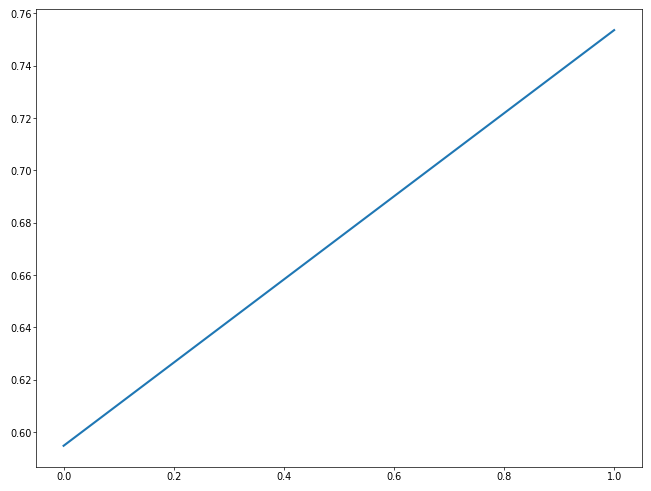

In [14]:
E_range = np.linspace(0,1,101)
R_range = dye_pixel_efficiency_Cy3[2]*(1-E_range) + dye_pixel_efficiency_Cy5[2]*(E_range)
plt.plot(E_range,R_range)

In [15]:
seg_df

,puncta_id,segment_number,frame_start,frame_end,n_points,A_R_mean,A_R_std,A_G_mean,A_G_std,A_B_mean,A_B_std,RG_ratio_mean,RG_ratio_std,photons_mean,photons_std
0,25,1,0,72,71,0.711321,0.035106,0.264980,0.027462,0.023699,0.017831,2.725294,0.407574,2385.501953,232.445206
1,25,2,73,124,46,0.674173,0.022576,0.310551,0.023882,0.015276,0.013143,2.188008,0.231415,2159.811523,438.295380
2,37,1,0,94,89,0.656509,0.024294,0.322184,0.021883,0.021307,0.014180,2.051169,0.206166,3333.149658,320.537018
3,37,2,95,177,78,0.684855,0.036769,0.291544,0.035562,0.023600,0.014422,2.398292,0.418981,2092.638184,758.463074
4,23,1,0,39,39,0.709684,0.040355,0.270337,0.039772,0.019979,0.017861,2.701231,0.546407,1322.955078,184.804504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117,426,4,126,724,543,0.656935,0.030103,0.328581,0.028596,0.014485,0.013514,2.020927,0.255245,2582.654541,666.934814
1118,582,1,0,38,36,0.689963,0.032164,0.296921,0.034197,0.013116,0.010041,2.373573,0.450192,3408.076904,1977.053711
1119,582,2,39,171,127,0.722165,0.030605,0.259149,0.027950,0.018686,0.013344,2.833619,0.451260,2363.968506,360.000366
1120,582,3,172,196,25,0.634926,0.044445,0.354935,0.043184,0.010140,0.017045,1.823172,0.305970,1598.095825,153.153290


In [16]:
def RGB_to_E_Cy3Cy5_cp(segs):
    """Converts an RGB value to the ESTIMATED FRET efficiency


    Args:
        segs: pd.DataFrame: average values per changepoint for RGB,photons,etc

    Returns:
        E: array: FRET Estimated FRET efficiencies not including quantum yield losses
    """
    d = dye_pixel_efficiency_Cy3 - dye_pixel_efficiency_Cy5
    denom = np.dot(d,d)
    X = np.array([segs['A_B_mean'],segs['A_G_mean'],segs['A_R_mean']])
    X = X.T
    num = np.einsum('ij,j->i', X - dye_pixel_efficiency_Cy5, d)  # (X - B) dot d, per row
    alpha = num/denom
    
        # Compute residuals
    recon = alpha[:, None] * dye_pixel_efficiency_Cy3 + (1.0 - alpha)[:, None] * dye_pixel_efficiency_Cy5
    residuals = np.sum((X - recon) ** 2, axis=1)
    residuals
    return(alpha,residuals)

In [17]:
def RGB_to_E_Cy3Cy5_data(data):
    """Converts an RGB value to the ESTIMATED FRET efficiency


    Args:
        segs: pd.DataFrame: average values per changepoint for RGB,photons,etc

    Returns:
        E: array: FRET Estimated FRET efficiencies not including quantum yield losses
    """
    d = dye_pixel_efficiency_Cy3 - dye_pixel_efficiency_Cy5
    denom = np.dot(d,d)
    X = np.array([data['A_B'],data['A_G'],data['A_R']])
    X = X.T
    num = np.einsum('ij,j->i', X - dye_pixel_efficiency_Cy5, d)  # (X - B) dot d, per row
    alpha = num/denom
    
        # Compute residuals
    recon = alpha[:, None] * dye_pixel_efficiency_Cy3 + (1.0 - alpha)[:, None] * dye_pixel_efficiency_Cy5
    residuals = np.sum((X - recon) ** 2, axis=1)
    residuals
    return(alpha,residuals)

In [18]:
[E_pseudo,residuals] = RGB_to_E_Cy3Cy5_cp(seg_df)

In [19]:
dye_pixel_efficiency_Cy3

array([0.02105954, 0.3841594 , 0.59478107])

In [20]:
Detection_Cy3

0.24984011240570875

In [21]:
gamma = (Detection_Cy5*1)/(Detection_Cy3*1)
print(gamma)
E_corrected = (E_pseudo/(E_pseudo + gamma*(1-E_pseudo)))

2.0131218745680712


In [22]:
#Cy5_incident = np.array(seg_df['photons_mean'])*E_pseudo/Detection_Cy5
#Cy3_incident = np.array(seg_df['photons_mean'])*(1-E_pseudo)/Detection_Cy3
#E_corrected = (Cy5_incident/0.29)/(Cy5_incident/0.29 + Cy3_incident/0.16)

In [23]:
Detection_Cy3

0.24984011240570875

(0.0, 1.0)

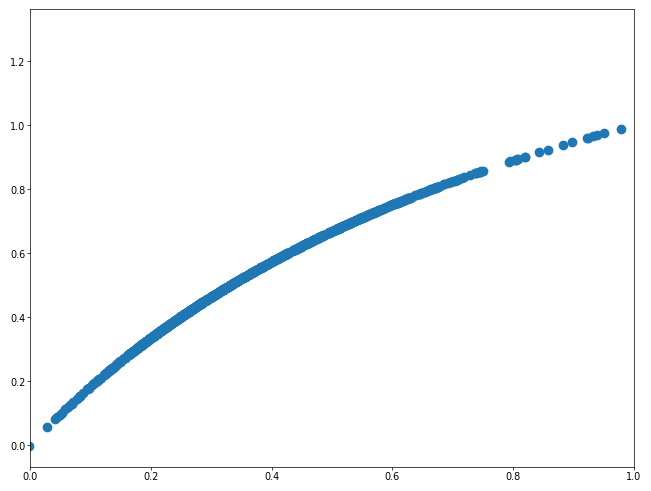

In [24]:
plt.scatter(E_corrected,E_pseudo)
plt.xlim([0,1])

1122


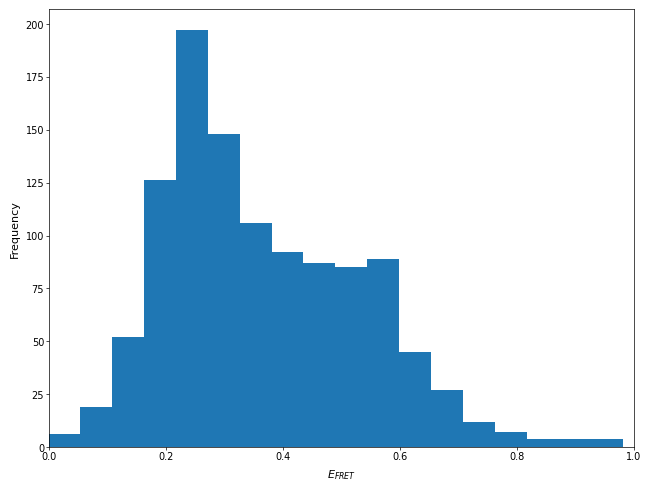

In [25]:
plt.hist(E_corrected,bins=np.histogram_bin_edges(E_corrected, 'sqrt'))
#plt.hist(E_pseudo,bins=np.histogram_bin_edges(E_pseudo, 'sqrt'))
plt.xlabel('$E_{FRET}$')
plt.ylabel('Frequency')
plt.xlim([0,1])
print(seg_df.shape[0])


(array([ 0.,  0.,  1.,  0.,  3.,  2.,  3.,  2.,  5.,  5.,  4.,  7.,  8.,
        14., 13.,  6., 16., 19., 24., 27., 22., 26., 35., 34., 33., 43.,
        39., 26., 31., 27., 28., 27., 26., 22., 14., 25., 18., 16., 21.,
        20., 18., 17., 16., 11., 16., 17., 22., 14.,  9., 11., 18., 21.,
        14., 12., 25., 18., 18., 21.,  8.,  8., 14., 10., 10.,  3.,  6.,
         5.,  8.,  7.,  2.,  4.,  3.,  3.,  1.,  3.,  5.,  0.,  0.,  0.,
         0.,  2.,  5.,  2.,  0.,  0.,  1.,  1.,  0.,  0.,  1.,  1.,  0.,
         0.,  2.,  2.,  1.,  0.,  0.,  1.,  0.,  0.]),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.

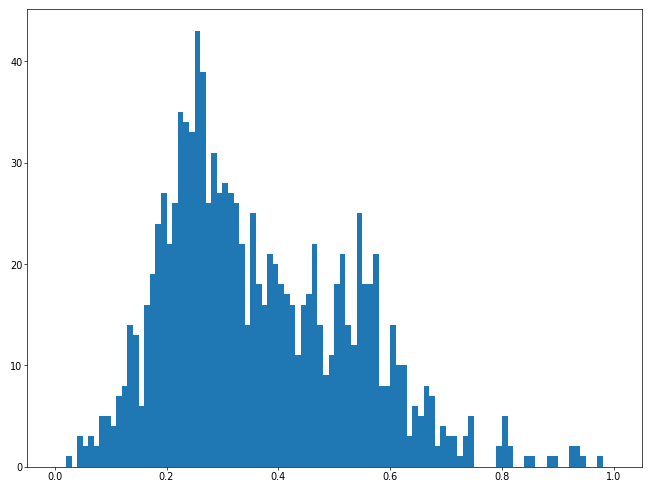

In [26]:
plt.hist(E_corrected,np.linspace(0,1,101))

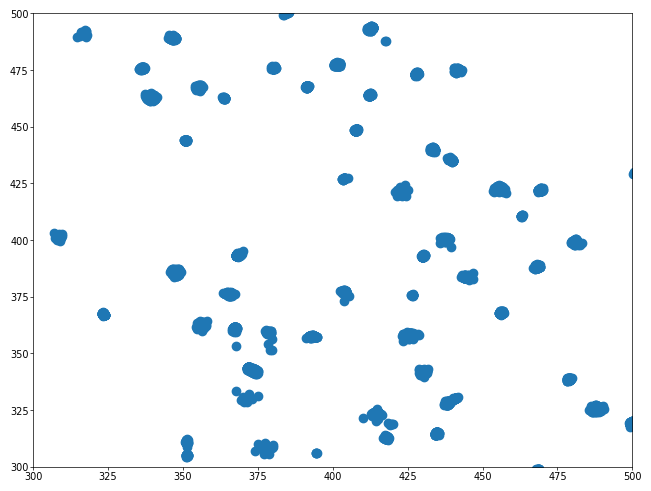

In [27]:
plt.scatter(df_data['xc'],df_data['yc'])
origin =400
ROI = 200 # pixel roi
x_begin = origin-ROI/2
x_end= origin + ROI/2

y_begin = origin-ROI/2
y_end= origin + ROI/2

plt.xlim([x_begin,x_end])
plt.ylim([y_begin,y_end])

ROI_true = (df_data['xc'] > x_begin)*(df_data['xc'] < x_end)*(df_data['yc'] > y_begin)*(df_data['yc'] < y_end)
ROI_df_data = df_data[ROI_true]

In [28]:
ROI_puncta_ID = np.sort(ROI_df_data['puncta_id'].unique())

In [29]:
# plot segment means for one punctum, 9, 14,15,20
exposure_time = 0.1
for i in range(ROI_puncta_ID.size):
    pid = ROI_puncta_ID[i]
    sub  = df_data[df_data['puncta_id'] == pid].sort_values('frame')
    segs = seg_df[seg_df['puncta_id'] == pid]
    cps  = cp_df[cp_df['puncta_id'] == pid]
    
    t = sub['frame'].values * exposure_time
   # plt.scatter(t, sub['A_R'], s=4, c='red')
   # for _, row in segs.iterrows():
   #     plt.hlines(row['A_R_mean'],
   #                row['frame_start'] * exposure_time,
   #                row['frame_end']   * exposure_time,
   #                colors='darkred', lw=2)
   # plt.scatter(t, sub['A_G'], s=4, c='green')
   # for _, row in segs.iterrows():
   #     plt.hlines(row['A_G_mean'],
   #                row['frame_start'] * exposure_time,
   #                row['frame_end']   * exposure_time,
   #                colors='darkgreen', lw=2)
   # for _, cp in cps.iterrows():
   #     plt.axvline(cp['frame'] * exposure_time, ls='--', color='k')
   # plt.title(['Puncta_ID = ',pid])
   # plt.show()
   # 
    #plt.scatter(t, sub['photons'], s=4, c='black')
    #for _, cp in cps.iterrows():
    #    plt.axvline(cp['frame'] * exposure_time, ls='--', color='k')
    #plt.title(['Puncta_ID = ',pid])

    #plt.show()


In [30]:
sub

,xc,yc,s_x,s_y,bg_B,bg_G,bg_R,A_B,A_G,A_R,...,bg_B_err,bg_G_err,bg_R_err,A_B_err,A_G_err,A_R_err,puncta_id,frame,photons,background_photons
107173,384.769135,500.907898,1.700631,1.679830,5.094481e-05,0.185170,0.814779,0.007624,0.337082,0.655295,...,0.220661,0.004637,0.005461,0.002310,0.000738,0.001127,511,0,2452.665039,25.972733
107174,384.359955,500.542389,1.735145,1.917842,2.353842e-04,0.225381,0.774383,0.003884,0.286089,0.710027,...,0.355008,0.004076,0.005234,0.001638,0.000558,0.000821,511,1,3163.206299,26.523045
107175,384.275208,500.359131,1.722097,1.854969,8.126166e-06,0.182931,0.817061,0.010922,0.288717,0.700361,...,0.469105,0.004078,0.005012,0.001054,0.000506,0.000768,511,3,3320.135254,27.333584
107176,384.531799,500.515076,1.781749,1.861187,4.075675e-04,0.207526,0.792067,0.014391,0.283321,0.702288,...,0.109606,0.004495,0.005585,0.001038,0.000593,0.000873,511,4,3189.962402,26.680618
107177,384.572296,500.722412,1.958838,1.631632,6.646626e-04,0.194839,0.804496,0.000321,0.284623,0.715056,...,0.058897,0.004621,0.005629,0.009469,0.000712,0.001074,511,5,2753.977295,27.104080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107451,384.943787,500.437073,2.052137,1.826608,5.200484e-04,0.196431,0.803049,0.000035,0.385882,0.614083,...,0.196893,0.005311,0.006261,0.023836,0.000779,0.001247,511,292,2578.017578,25.242847
107452,385.007690,500.744202,1.800951,1.591824,2.166090e-05,0.162615,0.837364,0.000423,0.375726,0.623851,...,0.367088,0.005792,0.006390,0.010457,0.000902,0.001415,511,293,2214.649902,24.460461
107453,385.141266,500.785858,1.995707,1.868116,2.009218e-04,0.218799,0.781000,0.006953,0.321397,0.671649,...,0.328017,0.005284,0.006533,0.001458,0.000670,0.001013,511,294,3056.620117,25.259073
107454,384.796478,500.431427,1.629822,1.528160,2.262628e-07,0.188940,0.811060,0.012859,0.368614,0.618527,...,0.296819,0.004566,0.005377,0.001992,0.000860,0.001319,511,295,2129.779297,26.052364


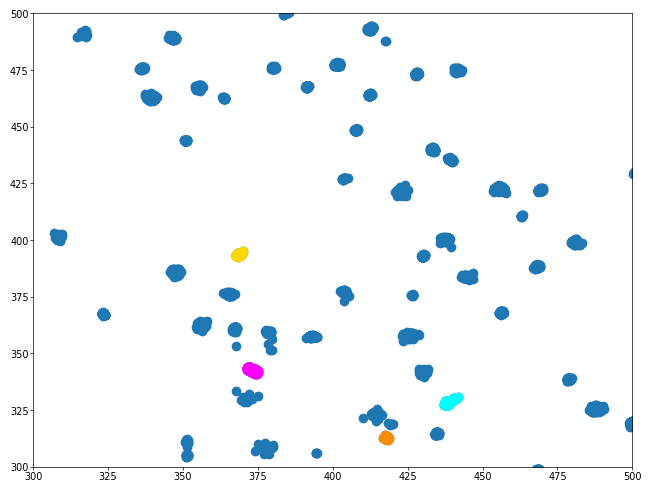

In [31]:
plt.scatter(df_data['xc'],df_data['yc'])
origin =400
ROI = 200 # pixel roi
x_begin = origin-ROI/2
x_end= origin + ROI/2

y_begin = origin-ROI/2
y_end= origin + ROI/2

plt.xlim([x_begin,x_end])
plt.ylim([y_begin,y_end])

ROI_true = (df_data['xc'] > x_begin)*(df_data['xc'] < x_end)*(df_data['yc'] > y_begin)*(df_data['yc'] < y_end)
ROI_df_data = df_data[ROI_true]
select_puncta = [327, 344, 355, 406]
color_select = ['darkorange','cyan','magenta','gold']
for i in range(4):
    sub  = df_data[df_data['puncta_id'] == select_puncta[i]].sort_values('frame')
    plt.scatter(sub['xc'],sub['yc'],c=color_select[i])


In [32]:
raw_image = IO.read_tiff(tiff_files[0])


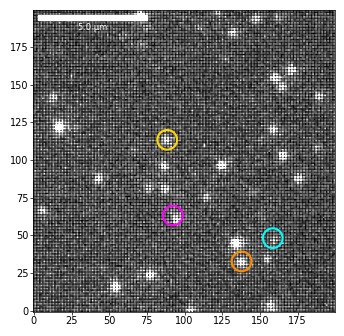

In [33]:
[fig, axs] = plotter.one_column_plot(1,[1])
plotter.create_image_plot(axs,raw_image[200,280:480,280:480],cmap='gray')
#plt.xlim([300,500])
#plt.ylim([300,500])
plotter.add_scalebar(axs,69,5000,'upper left')
for i in range(4):
    sub  = df_data[df_data['puncta_id'] == select_puncta[i]].sort_values('frame')
    xc_coord = np.mean(sub['xc']) - 280
    yc_coord = np.mean(sub['yc']) -280
    plt.scatter(xc_coord,yc_coord,edgecolors=color_select[i],s=200,facecolors='none',linewidths=1.5)
#folder_tosave = r'C:\Users\kbhc756\temp_data\figs_for_joe_Durham'
#plt.savefig(os.path.join(folder_tosave, 'SelectPoints.svg'), dpi=600, format='svg')

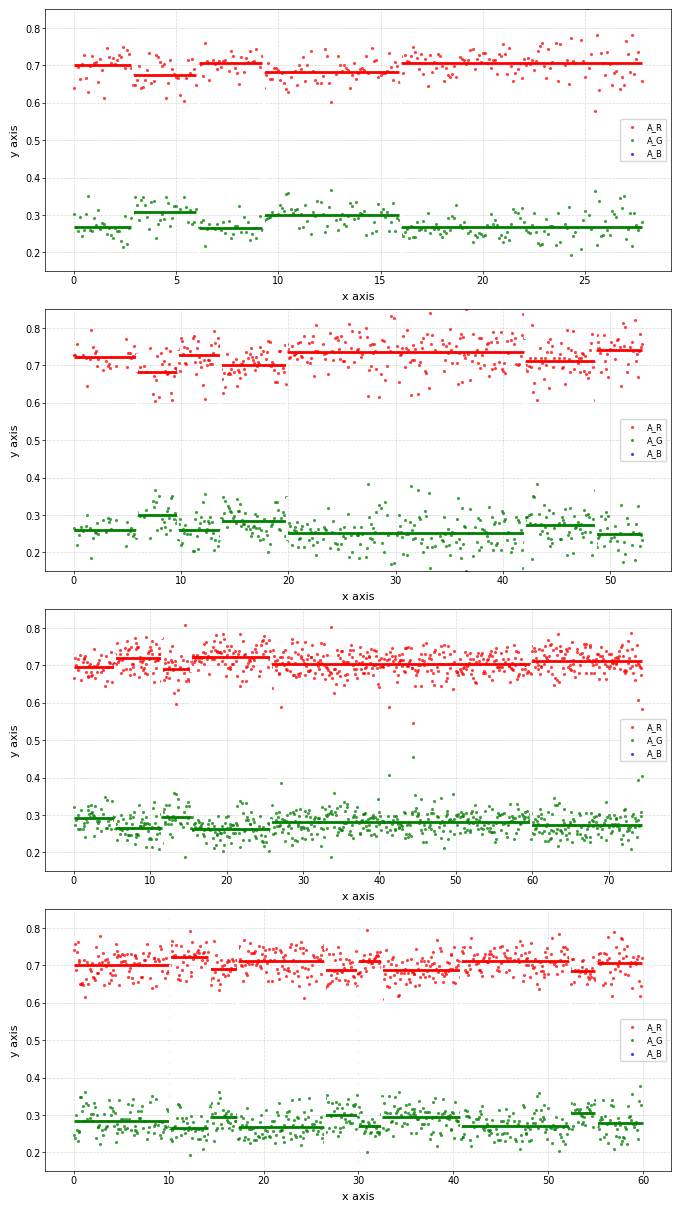

In [34]:
fig, axs = plotter.two_column_plot(nrows=4, heightratio=[1, 1, 1, 1])
exposure_time = 0.1
for i in range(4):
    pid = select_puncta[i]
    sub  = df_data[df_data['puncta_id'] == pid].sort_values('frame')
    segs = seg_df[seg_df['puncta_id'] == pid]
    cps  = cp_df[cp_df['puncta_id'] == pid]
    
    t = sub['frame'].values * exposure_time
    axs[i] = plotter.scatter_plot(axs[i],t, sub['A_R'], s=5, facecolor='red', lw=0, label='A_R',alpha=0.75)
    axs[i] = plotter.scatter_plot(axs[i],t, sub['A_G'], s=5, facecolor='green', lw=0, label='A_G',alpha=0.75)
    axs[i] = plotter.scatter_plot(axs[i],t, sub['A_B'], s=5, facecolor='blue', lw=0, label='A_B',alpha=0.75,ylim=[0.15,0.85])

    for _, row in segs.iterrows():
        axs[i].hlines(row['A_R_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='red', lw=2)
    for _, row in segs.iterrows():
        axs[i].hlines(row['A_G_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='green', lw=2)
    for _, row in segs.iterrows():
        axs[i].hlines(row['A_B_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='blue', lw=2)
    for _, cp in cps.iterrows():
        axs[i].axvline(cp['frame'] * exposure_time, ls='--', color='white')
#folder_tosave = r'C:\Users\kbhc756\temp_data\figs_for_joe_Durham'
#plt.savefig(os.path.join(folder_tosave, 'changepoints.svg'), dpi=600, format='svg')

In [35]:
changepoint_files[24]

'/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/FRET/20pM_HJ_200mM_MgCl2/20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos004_004_colourchangepoint.h5'

In [36]:
dfs = []
cp_dfs = []
seg_dfs = []
dwell_dfs = []
for i in range(24) : 
    [df_data, cp_df, seg_df] = load_changepoint_analysis(changepoint_files[i])
    dfs.append(df_data)
    cp_dfs.append(cp_df)
    seg_dfs.append(seg_df)
    puncta_ids = seg_df['puncta_id'].unique()
    loops = len(puncta_ids) - 1
    for ii in range(loops):
        puncta_seg_df = seg_df[seg_df['puncta_id']==puncta_ids[ii]]
        puncta_seg_df['DeltaR'] = puncta_seg_df[:]['A_R_mean'] - puncta_seg_df[:]['A_R_mean'].shift(-1) # how did the colour change from the last CP
        if len(puncta_seg_df) < 3:
            dwell_df = pd.DataFrame()
        else:
            dwell_df = pd.DataFrame(puncta_seg_df[1:-1])
        dwell_dfs.append(dwell_df) #doesn't work, saves them as a list.  Need to get them to stack across over the for loop
    

final_df_data = pd.concat(dfs)
final_cp_df = pd.concat(cp_dfs)
final_seg_df = pd.concat(seg_dfs)
final_dwell_df = pd.concat(dwell_dfs)




/tmp/ipykernel_2387787/3392531833.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puncta_seg_df['DeltaR'] = puncta_seg_df[:]['A_R_mean'] - puncta_seg_df[:]['A_R_mean'].shift(-1) # how did the colour change from the last CP
/tmp/ipykernel_2387787/3392531833.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puncta_seg_df['DeltaR'] = puncta_seg_df[:]['A_R_mean'] - puncta_seg_df[:]['A_R_mean'].shift(-1) # how did the colour change from the last CP
/tmp/ipykernel_2387787/3392531833.py:14: SettingWithCopy

In [37]:
final_dwell_df

,puncta_id,segment_number,frame_start,frame_end,n_points,A_R_mean,A_R_std,A_G_mean,A_G_std,A_B_mean,A_B_std,RG_ratio_mean,RG_ratio_std,photons_mean,photons_std,DeltaR
5,23,2,40,94,49,0.678004,0.042474,0.305031,0.043879,0.016966,0.018348,2.284043,0.449772,1342.626953,388.068481,0.051364
8,33,2,39,81,41,0.708055,0.049790,0.277205,0.047430,0.014741,0.014562,2.652961,0.608736,1098.831177,164.215164,0.051255
9,33,3,82,113,25,0.656800,0.048841,0.325844,0.051576,0.017356,0.018592,2.082541,0.451105,1058.988647,223.580597,-0.043952
16,36,2,477,566,25,0.579021,0.178431,0.414254,0.180145,0.006724,0.009822,1.701184,0.806507,704.535095,227.924576,-0.075183
21,38,2,104,145,27,0.647555,0.052243,0.334470,0.045211,0.017975,0.017724,1.990881,0.438967,1208.506226,325.573456,-0.053505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1259,539,2,684,734,49,0.711554,0.021802,0.280306,0.020132,0.008140,0.009957,2.555623,0.247157,4047.040771,524.120239,-0.024171
1260,539,3,736,762,27,0.735725,0.018527,0.255911,0.017894,0.008364,0.008045,2.893429,0.278435,3049.003662,782.982849,-0.014006
1263,649,2,230,692,435,0.732907,0.048771,0.242859,0.044291,0.024234,0.020650,3.159988,0.826395,1163.915894,287.152405,0.032085
1264,649,3,693,757,57,0.700822,0.055664,0.276011,0.052028,0.023167,0.019678,2.676060,0.771607,975.673645,237.516464,-0.026108


In [38]:
[E_all,residuals_all] = RGB_to_E_Cy3Cy5_cp(final_seg_df)

2.0131218745680712


(array([  21.,   47.,   88.,  104.,  188.,  236.,  421.,  612.,  846.,
        1124., 1425., 1517., 1712., 1486., 1338., 1209., 1180., 1150.,
        1032.,  978.,  866.,  801.,  672.,  718.,  731.,  824.,  757.,
         781.,  694.,  543.,  492.,  345.,  303.,  223.,  169.,  154.,
         145.,  109.,   78.,   86.,   74.,   58.,   42.,   41.,   42.,
          36.,   35.,   38.,   19.,   23.]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 <BarContainer object of 50 artists>)

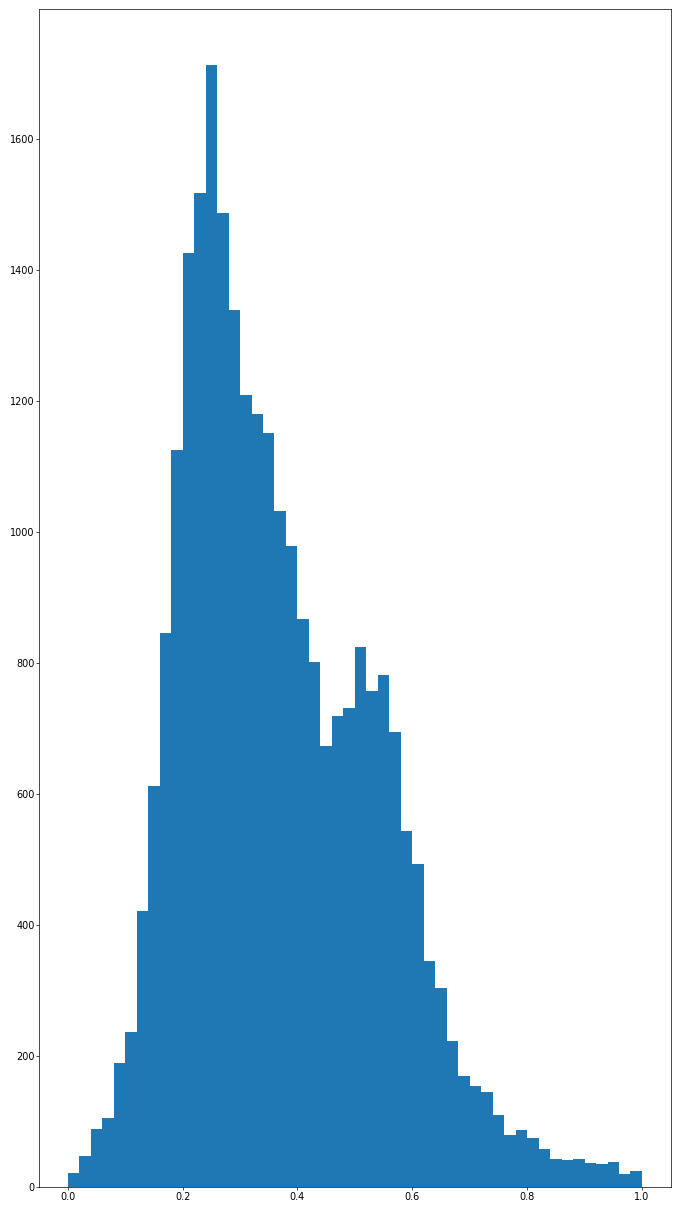

In [39]:
#Cy5_incident = np.array(final_seg_df['photons_mean'])*E_all/Detection_Cy5
#Cy3_incident = np.array(final_seg_df['photons_mean'])*(1-E_all)/Detection_Cy3
#E_corrected = (Cy5_incident*0.29)/(Cy5_incident*0.29 + Cy3_incident*0.16)
gamma = (Detection_Cy5*1)/(Detection_Cy3*1)
print(gamma)
E_corrected = (E_all/(E_all + gamma*(1-E_all)))

plt.hist(E_corrected,np.linspace(0,1,51))

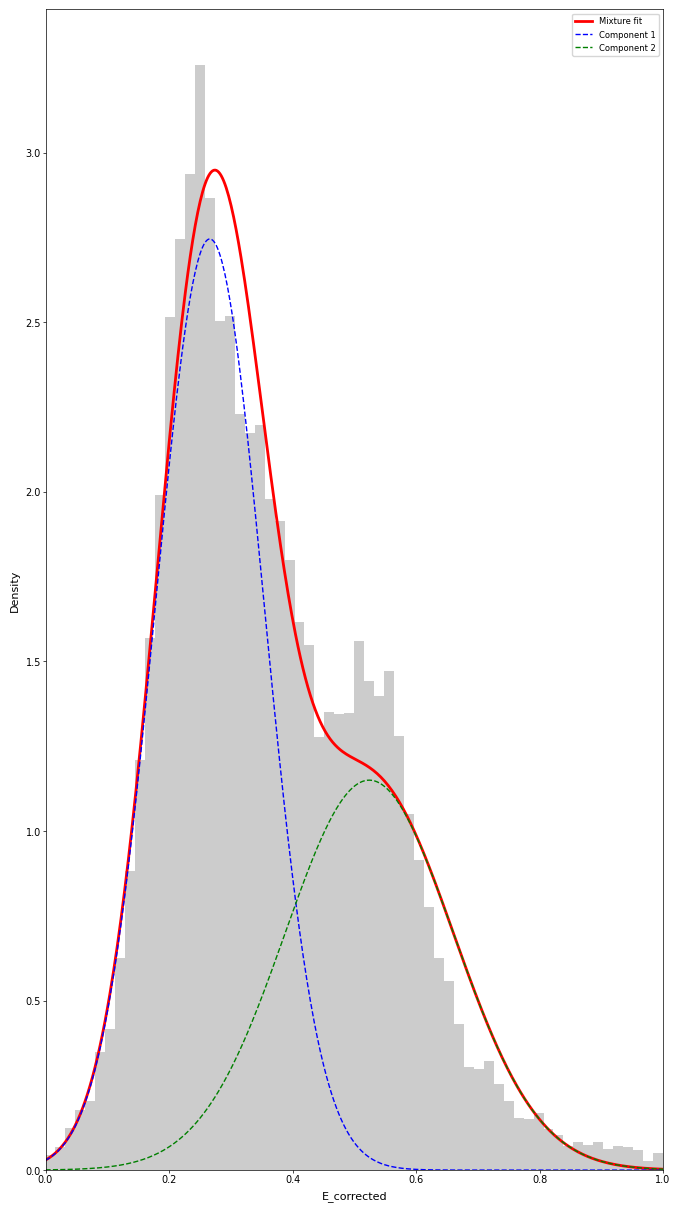

[0.26608646 0.52427898]
[0.60665076 0.39334924]


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# E_corrected: 1D numpy array
X = np.asarray(E_corrected).ravel()  # restrict to [0,1]
X = X[(X >= 0) & (X <= 1)].reshape(-1, 1)

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0).fit(X)

xs = np.linspace(0, 1, 500).reshape(-1, 1)
pdf_mix = np.exp(gmm.score_samples(xs))

# Component PDFs
means = gmm.means_.ravel()
vars_ = np.array([np.diag(cov)[0] for cov in gmm.covariances_])
weights = gmm.weights_
pdf_comps = np.array([
    weights[k] * (1/np.sqrt(2*np.pi*vars_[k])) * np.exp(-0.5*((xs.ravel()-means[k])**2)/vars_[k])
    for k in range(2)
])

fig, ax = plt.subplots()
ax.hist(X.ravel(), bins='auto', range=(0,1), density=True, alpha=0.4, color='gray', edgecolor='none')
ax.plot(xs, pdf_mix, 'r-', lw=2, label='Mixture fit')
ax.plot(xs, pdf_comps[0], 'b--', lw=1, label='Component 1')
ax.plot(xs, pdf_comps[1], 'g--', lw=1, label='Component 2')
ax.set_xlim(0, 1); ax.set_xlabel('E_corrected'); ax.set_ylabel('Density'); ax.legend(); plt.show()
print(means)
print(weights)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\kbhc756\\temp_data\\TempFigure3/FRET_Apparent_Corrected.svg'

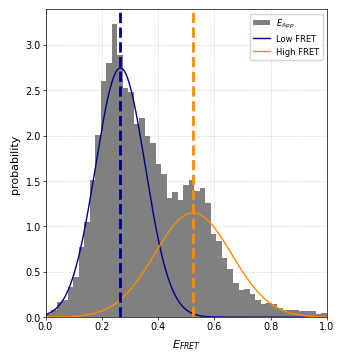

In [41]:
[fig, axs] = plotter.one_column_plot(1,[1])
axs = plotter.histogram_plot(axs,X,bins=51,xlim=[0,1],label='$E_{App}$')
#axs = plotter.line_plot(axs,xs,pdf_mix,color='black',lw=1,label='Combined Fit')
axs = plotter.line_plot(axs,xs,pdf_comps[0],color='darkblue',lw=1,label='Low FRET')
axs = plotter.line_plot(axs,xs,pdf_comps[1],color='darkorange',lw=1,label = 'High FRET')
axs.set_xlabel('$E_{FRET}$')
axs.set_ylabel('probability')
axs.legend()
axs.axvline(means[0],linewidth=2,color='darkblue',linestyle='--')
axs.axvline(means[1],linewidth=2,color='darkorange',linestyle='--')
folder_tosave = r'C:\Users\kbhc756\temp_data\TempFigure3'

plt.savefig(os.path.join(folder_tosave, 'FRET_Apparent_Corrected.svg'), dpi=600, format='svg')

In [ ]:

[fig, axs] = plotter.one_column_plot(1,[1])
axs = plotter.histogram_plot(axs,E_all,bins=201,xlim=[0,1])
print(['changpoints = ',E_all.size])
print(['N Molecules = ',final_cp_df.shape[0]])
folder_tosave = r'C:\Users\kbhc756\temp_data\figs_for_joe_Durham'
#plt.savefig(os.path.join(folder_tosave, 'FRET_efficiency.svg'), dpi=600, format='svg')

(0.0, 1.0)

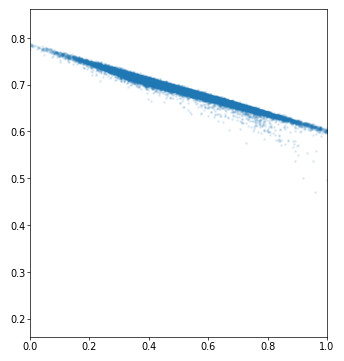

In [42]:
plt.scatter(E_all,final_seg_df['A_R_mean'],s=1,alpha=0.1)
plt.xlim([0,1])
#plt.ylim([0,4])

In [43]:
final_seg_df

,puncta_id,segment_number,frame_start,frame_end,n_points,A_R_mean,A_R_std,A_G_mean,A_G_std,A_B_mean,A_B_std,RG_ratio_mean,RG_ratio_std,photons_mean,photons_std
0,25,1,0,72,71,0.711321,0.035106,0.264980,0.027462,0.023699,0.017831,2.725294,0.407574,2385.501953,232.445206
1,25,2,73,124,46,0.674173,0.022576,0.310551,0.023882,0.015276,0.013143,2.188008,0.231415,2159.811523,438.295380
2,37,1,0,94,89,0.656509,0.024294,0.322184,0.021883,0.021307,0.014180,2.051169,0.206166,3333.149658,320.537018
3,37,2,95,177,78,0.684855,0.036769,0.291544,0.035562,0.023600,0.014422,2.398292,0.418981,2092.638184,758.463074
4,23,1,0,39,39,0.709684,0.040355,0.270337,0.039772,0.019979,0.017861,2.701231,0.546407,1322.955078,184.804504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266,553,1,0,60,56,0.714375,0.034469,0.272190,0.034707,0.013434,0.011019,2.682527,0.468931,2010.843628,288.006958
1267,553,2,61,178,111,0.698013,0.025818,0.287170,0.025210,0.014817,0.012908,2.455714,0.295129,2405.116211,476.760071
1268,553,3,180,851,635,0.654660,0.029540,0.331627,0.028413,0.013714,0.013839,1.995474,0.256070,2177.614258,498.853485
1269,638,1,0,38,36,0.706464,0.066569,0.276509,0.065228,0.017027,0.013207,2.793878,1.121429,1239.071289,264.916260


In [44]:
final_seg_df

,puncta_id,segment_number,frame_start,frame_end,n_points,A_R_mean,A_R_std,A_G_mean,A_G_std,A_B_mean,A_B_std,RG_ratio_mean,RG_ratio_std,photons_mean,photons_std
0,25,1,0,72,71,0.711321,0.035106,0.264980,0.027462,0.023699,0.017831,2.725294,0.407574,2385.501953,232.445206
1,25,2,73,124,46,0.674173,0.022576,0.310551,0.023882,0.015276,0.013143,2.188008,0.231415,2159.811523,438.295380
2,37,1,0,94,89,0.656509,0.024294,0.322184,0.021883,0.021307,0.014180,2.051169,0.206166,3333.149658,320.537018
3,37,2,95,177,78,0.684855,0.036769,0.291544,0.035562,0.023600,0.014422,2.398292,0.418981,2092.638184,758.463074
4,23,1,0,39,39,0.709684,0.040355,0.270337,0.039772,0.019979,0.017861,2.701231,0.546407,1322.955078,184.804504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266,553,1,0,60,56,0.714375,0.034469,0.272190,0.034707,0.013434,0.011019,2.682527,0.468931,2010.843628,288.006958
1267,553,2,61,178,111,0.698013,0.025818,0.287170,0.025210,0.014817,0.012908,2.455714,0.295129,2405.116211,476.760071
1268,553,3,180,851,635,0.654660,0.029540,0.331627,0.028413,0.013714,0.013839,1.995474,0.256070,2177.614258,498.853485
1269,638,1,0,38,36,0.706464,0.066569,0.276509,0.065228,0.017027,0.013207,2.793878,1.121429,1239.071289,264.916260


In [45]:
[df_data, cp_df, seg_df] = load_changepoint_analysis(changepoint_files[0])

In [ ]:

fig, axs = plotter.two_column_plot(nrows=4, heightratio=[1, 1, 1, 1])
select_puncta = [327, 344, 355, 406]

exposure_time = 0.1
for i in range(4):
    pid = select_puncta[i]
    sub  = df_data[df_data['puncta_id'] == pid].sort_values('frame')
    segs = seg_df[seg_df['puncta_id'] == pid]
    cps  = cp_df[cp_df['puncta_id'] == pid]
    
    t = sub['frame'].values * exposure_time
    axs[i] = plotter.scatter_plot(axs[i],t, sub['A_R'], s=5, facecolor='red', lw=0, label='A_R',alpha=0.75)
    axs[i] = plotter.scatter_plot(axs[i],t, sub['A_G'], s=5, facecolor='green', lw=0, label='A_G',alpha=0.75)
    axs[i] = plotter.scatter_plot(axs[i],t, sub['A_B'], s=5, facecolor='blue', lw=0, label='A_B',alpha=0.75)

    for _, row in segs.iterrows():
        axs[i].hlines(row['A_R_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='red', lw=2)
    for _, row in segs.iterrows():
        axs[i].hlines(row['A_G_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='green', lw=2)
    for _, row in segs.iterrows():
        axs[i].hlines(row['A_B_mean'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='blue', lw=2)
    for _, cp in cps.iterrows():
        axs[i].axvline(cp['frame'] * exposure_time, ls='--', color='white')
    del sub    
#folder_tosave = r'C:\Users\kbhc756\temp_data\figs_for_joe_Durham'
#plt.savefig(os.path.join(folder_tosave, 'changepoints.svg'), dpi=600, format='svg')

In [ ]:

fig, axs = plotter.two_column_plot(nrows=4, heightratio=[1, 1, 1, 1])
select_puncta = [327, 344, 355, 406]

exposure_time = 0.1
for i in range(4):
    pid = select_puncta[i]
    sub  = df_data[df_data['puncta_id'] == pid].sort_values('frame')
    segs = seg_df[seg_df['puncta_id'] == pid]
    cps  = cp_df[cp_df['puncta_id'] == pid]

    [E_sub,residual] = RGB_to_E_Cy3Cy5_data(sub)
    [E_seg,residual] = RGB_to_E_Cy3Cy5_cp(segs)
    segs['E_seg'] = E_seg.T
    t = sub['frame'].values * exposure_time
    #axs[i] = plotter.scatter_plot(axs[i],t, sub['A_R'], s=5, facecolor='red', lw=0, label='A_R',alpha=0.75)
    #axs[i] = plotter.scatter_plot(axs[i],t, sub['A_G'], s=5, facecolor='green', lw=0, label='A_G',alpha=0.75)
    #axs[i] = plotter.scatter_plot(axs[i],t, sub['A_B'], s=5, facecolor='blue', lw=0, label='A_B',alpha=0.75)

    axs[i] = plotter.scatter_plot(axs[i],t,E_sub, s=5, facecolor='orange',lw=0,label='E',alpha=0.75,ylim=[0,1])
    for _, row in segs.iterrows():
        axs[i].hlines(row['E_seg'],
                   row['frame_start'] * exposure_time,
                   row['frame_end']   * exposure_time,
                   colors='orange', lw=2)
    #for _, row in segs.iterrows():
    #    axs[i].hlines(row['A_R_mean'],
    #               row['frame_start'] * exposure_time,
    #               row['frame_end']   * exposure_time,
    #               colors='red', lw=2)
    #for _, row in segs.iterrows():
    #    axs[i].hlines(row['A_G_mean'],
    #               row['frame_start'] * exposure_time,
    #               row['frame_end']   * exposure_time,
    #               colors='green', lw=2)
    #for _, row in segs.iterrows():
    #    axs[i].hlines(row['A_B_mean'],
    #               row['frame_start'] * exposure_time,
    #               row['frame_end']   * exposure_time,
    #               colors='blue', lw=2)
    for _, cp in cps.iterrows():
        axs[i].axvline(cp['frame'] * exposure_time, ls='--', color='white')

In [ ]:
plt.hist(E_sub,np.linspace(0,1,21))

In [ ]:
E_seg

In [ ]:
dwell_time_seconds = (exposure_time*final_dwell_df['frame_end'] - exposure_time*final_dwell_df['frame_start'])
[fig, axs] = plotter.one_column_plot(1,[1])
axs = plotter.histogram_plot(axs,dwell_time_seconds,bins=101)
folder_tosave = r'C:\Users\kbhc756\temp_data\figs_for_joe_Durham'
#plt.savefig(os.path.join(folder_tosave, 'FRET_efficiency.svg'), dpi=600, format='svg')


(array([  5.,   7.,   9.,  12.,  11.,  19.,  15.,  24.,  28.,  29.,  41.,
         53.,  51.,  70.,  59.,  80.,  73.,  69.,  71.,  75.,  88., 102.,
         66.,  92.,  81.,  83.,  72.,  84., 101.,  84.,  93.,  98., 109.,
        120., 124., 149., 150., 162., 156., 136., 129., 130., 147., 122.,
        115.,  84., 117.,  74.,  79.,  76.,  58.,  44.,  60.,  41.,  35.,
         48.,  32.,  29.,  26.,  27.,  25.,  23.,  14.,  12.,  18.,   9.,
         11.,  15.,  11.,   6.,   5.,   5.,   7.,   4.,   4.,   1.,   5.,
          5.,   1.,   5.,   1.,   0.,   4.,   0.,   1.,   0.,   2.,   0.,
          0.,   2.,   1.,   1.,   0.,   0.,   1.,   0.,   0.,   1.,   1.,
          2.]),
 array([1.5 , 1.52, 1.54, 1.56, 1.58, 1.6 , 1.62, 1.64, 1.66, 1.68, 1.7 ,
        1.72, 1.74, 1.76, 1.78, 1.8 , 1.82, 1.84, 1.86, 1.88, 1.9 , 1.92,
        1.94, 1.96, 1.98, 2.  , 2.02, 2.04, 2.06, 2.08, 2.1 , 2.12, 2.14,
        2.16, 2.18, 2.2 , 2.22, 2.24, 2.26, 2.28, 2.3 , 2.32, 2.34, 2.36,
        2.38, 2.4 , 2.

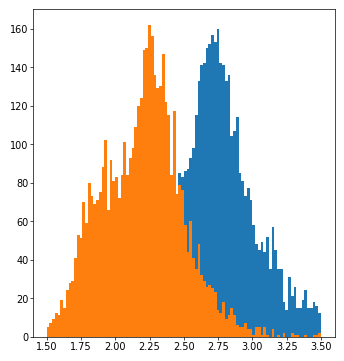

In [46]:
final_HighFRET_dwell_df = final_dwell_df[final_dwell_df['DeltaR']>0]
final_LowFRET_dwell_df = final_dwell_df[final_dwell_df['DeltaR']<0]
final_LowFRET_dwell_df
plt.hist(final_HighFRET_dwell_df['RG_ratio_mean'],np.linspace(1.5,3.5,101))
plt.hist(final_LowFRET_dwell_df['RG_ratio_mean'],np.linspace(1.5,3.5,101))


In [47]:
test = RGB_to_E_Cy3Cy5_cp(final_HighFRET_dwell_df)

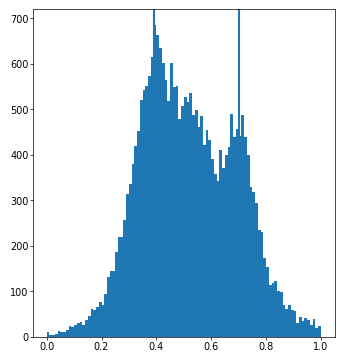

In [48]:
plt.hist(E_all,np.linspace(0,1,101))
plt.axvline(0.39)
plt.axvline(0.7)

/tmp/ipykernel_2387787/1948988504.py:8: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)


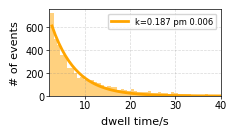

0.18669264991797022
0.0060650505128096895


In [52]:
from scipy.optimize import curve_fit
def exp_decay(x, a, b):
    """
    Exponential decay function: y = a * exp(-b * x)
    a: initial amplitude
    b: decay rate
    """
    return a * np.exp(-b * x)

dwell_timeHighFRET_seconds = (exposure_time*final_HighFRET_dwell_df['frame_end'] - exposure_time*final_HighFRET_dwell_df['frame_start'])

#points width 120, height 150
counts, bin_edges = np.histogram(dwell_timeHighFRET_seconds, bins=101, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Midpoints of bins
initial_guess = [counts.max(), 1.0]
try:
    popt, pcov = curve_fit(exp_decay, bin_centers, counts, p0=initial_guess)
    fitted_a, fitted_b = popt
    perr = np.sqrt(np.diag(pcov))
except RuntimeError:
    print("Error: Curve fitting failed.")
    exit(1)

    
[fig, axs] = plotter.one_column_plot(1,[1],width=2.25,height=2.5/2)
axs = plotter.histogram_plot(axs,dwell_timeHighFRET_seconds,bin_edges,density=False,histcolor='orange',alpha=0.5, xaxislabel='dwell time/s')
axs = plotter.line_plot(axs,bin_centers,exp_decay(bin_centers, *popt),color='orange',lw=2,
                       xaxislabel='dwell time/s', yaxislabel='# of events', label=f'k={np.around(popt[1], 3)} pm {np.around(perr[1], 3)}')
axs.set_xlim([2, 40])
folder_tosave = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/FRET'
plt.savefig(os.path.join(folder_tosave, 'Dwell_TimeHighFRET_Histogram_narrow.svg'), dpi=600, format='svg')
#axs.set_yscale('log')
plt.show()

print(popt[1])
print(perr[1])

/tmp/ipykernel_2387787/3359460157.py:8: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)
/tmp/ipykernel_2387787/3359460157.py:8: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x)


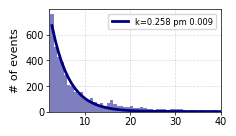

0.2578523914947026


In [56]:
from scipy.optimize import curve_fit
def exp_decay(x, a, b):
    """
    Exponential decay function: y = a * exp(-b * x)
    a: initial amplitude
    b: decay rate
    """
    return a * np.exp(-b * x)

dwell_timeLowFRET_seconds = (exposure_time*final_LowFRET_dwell_df['frame_end'] - exposure_time*final_LowFRET_dwell_df['frame_start'])


counts, bin_edges = np.histogram(dwell_timeLowFRET_seconds, bins=101, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Midpoints of bins
initial_guess = [counts.max(), 1.0]
try:
    popt, pcov = curve_fit(exp_decay, bin_centers, counts, p0=initial_guess)
    fitted_a, fitted_b = popt
    perr = np.sqrt(np.diagonal(pcov))
except RuntimeError:
    print("Error: Curve fitting failed.")
    exit(1)

    
[fig, axs] = plotter.one_column_plot(1,[1],width=2.25,height=2.5/2)
axs = plotter.histogram_plot(axs,dwell_timeLowFRET_seconds,bin_edges,density=False,histcolor='#000080',alpha=0.5)
axs = plotter.line_plot(axs,bin_centers,exp_decay(bin_centers, *popt),color='#000080',lw=2,
                       xaxislabel='', yaxislabel='# of events', label=f'k={np.around(popt[1], 3)} pm {np.around(perr[1], 3)}')
axs.set_xlabel('')
folder_tosave = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/FRET'
axs.set_xlim([2, 40])
plt.savefig(os.path.join(folder_tosave, 'Dwell_TimeLowFRET_Histogram_narrow.svg'), dpi=600, format='svg')
#axs.set_yscale('log')
plt.show()

print(popt[1])

In [ ]:
plt.hist(dwell_time_seconds,bin_edges)
plt.plot(bin_centers,exp_decay(bin_centers, *popt),color='r')

In [ ]:
dwell_timeHighFRET_seconds = (exposure_time*final_HighFRET_dwell_df['frame_end'] - exposure_time*final_HighFRET_dwell_df['frame_start'])

#points width 120, height 150
counts, bin_edges = np.histogram(dwell_timeHighFRET_seconds, bins=101, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Midpoints of bins
initial_guess = [counts.max(), 1.0]
try:
    popt, pcov = curve_fit(exp_decay, bin_centers, counts, p0=initial_guess)
    fitted_a, fitted_b = popt
except RuntimeError:
    print("Error: Curve fitting failed.")
    exit(1)

    

[fig, axs] = plotter.two_column_plot(nrows=1,ncolumns=2,heightratio=[1],widthratio=[1,1],width=144/72,height=62/72)

axs[0] = plotter.histogram_plot(axs[0],dwell_timeHighFRET_seconds,bin_edges,density=False,histcolor='orange',alpha=0.5)
axs[0] = plotter.line_plot(axs[0],bin_centers,exp_decay(bin_centers, *popt),color='orange',lw=2)


dwell_timeLowFRET_seconds = (exposure_time*final_LowFRET_dwell_df['frame_end'] - exposure_time*final_LowFRET_dwell_df['frame_start'])


counts, bin_edges = np.histogram(dwell_timeLowFRET_seconds, bins=101, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Midpoints of bins
initial_guess = [counts.max(), 1.0]
try:
    popt, pcov = curve_fit(exp_decay, bin_centers, counts, p0=initial_guess)
    fitted_a, fitted_b = popt
except RuntimeError:
    print("Error: Curve fitting failed.")
    exit(1)

axs[1] = plotter.histogram_plot(axs[1],dwell_timeLowFRET_seconds,bin_edges,density=False,histcolor='cyan',alpha=0.5)
axs[1] = plotter.line_plot(axs[1],bin_centers,exp_decay(bin_centers, *popt),color='cyan',lw=2)
folder_tosave = r'C:\Users\kbhc756\temp_data\figs_for_joe_Durham'
plt.savefig(os.path.join(folder_tosave, 'Dwell_TimeBothFRET_small.svg'), dpi=600, format='svg')